In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mathchi/diabetes-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes-data-set' dataset.
Path to dataset files: /kaggle/input/diabetes-data-set


In [ ]:
import pandas as pd
import os
df=pd.read_csv(os.path.join(path,'diabetes.csv'))


In [ ]:
df=pd.read_csv('diabetes.csv')

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
1531,10,101,76,48,180,32.9,0.171,63,0
1532,2,122,70,27,0,36.8,0.340,27,0
1533,5,121,72,23,112,26.2,0.245,30,0
1534,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1536 entries, 0 to 1535
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1536 non-null   int64  
 1   Glucose                   1536 non-null   int64  
 2   BloodPressure             1536 non-null   int64  
 3   SkinThickness             1536 non-null   int64  
 4   Insulin                   1536 non-null   int64  
 5   BMI                       1536 non-null   float64
 6   DiabetesPedigreeFunction  1536 non-null   float64
 7   Age                       1536 non-null   int64  
 8   Outcome                   1536 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 108.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000,1536.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.368480,31.962202,19.349501,15.947021,115.206457,7.881592,0.331221,11.756400,0.476796
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df['Outcome'].value_counts()

,count
Outcome,
0,1000
1,536


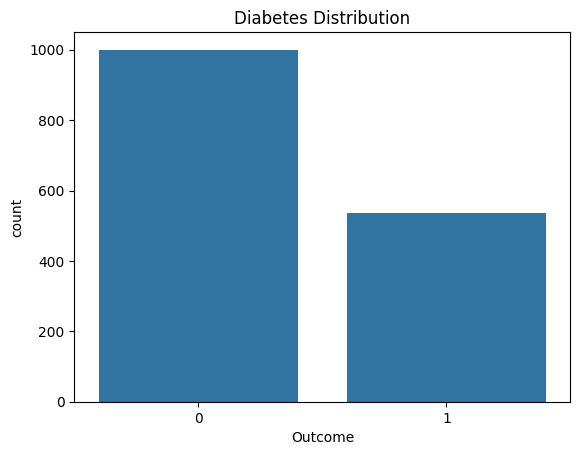

In [ ]:
sns.countplot(x='Outcome',data=df)
plt.title("Diabetes Distribution")
plt.show()

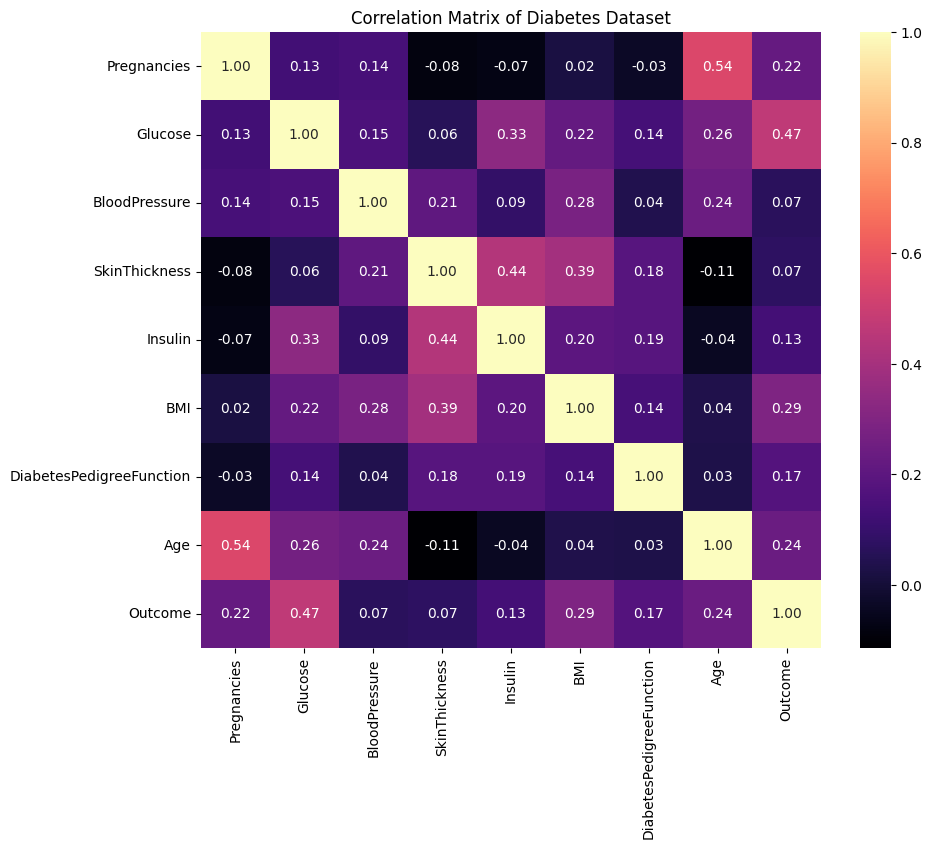

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='magma', fmt='.2f')
plt.title('Correlation Matrix of Diabetes Dataset')
plt.show()

<Figure size 1000x800 with 0 Axes>

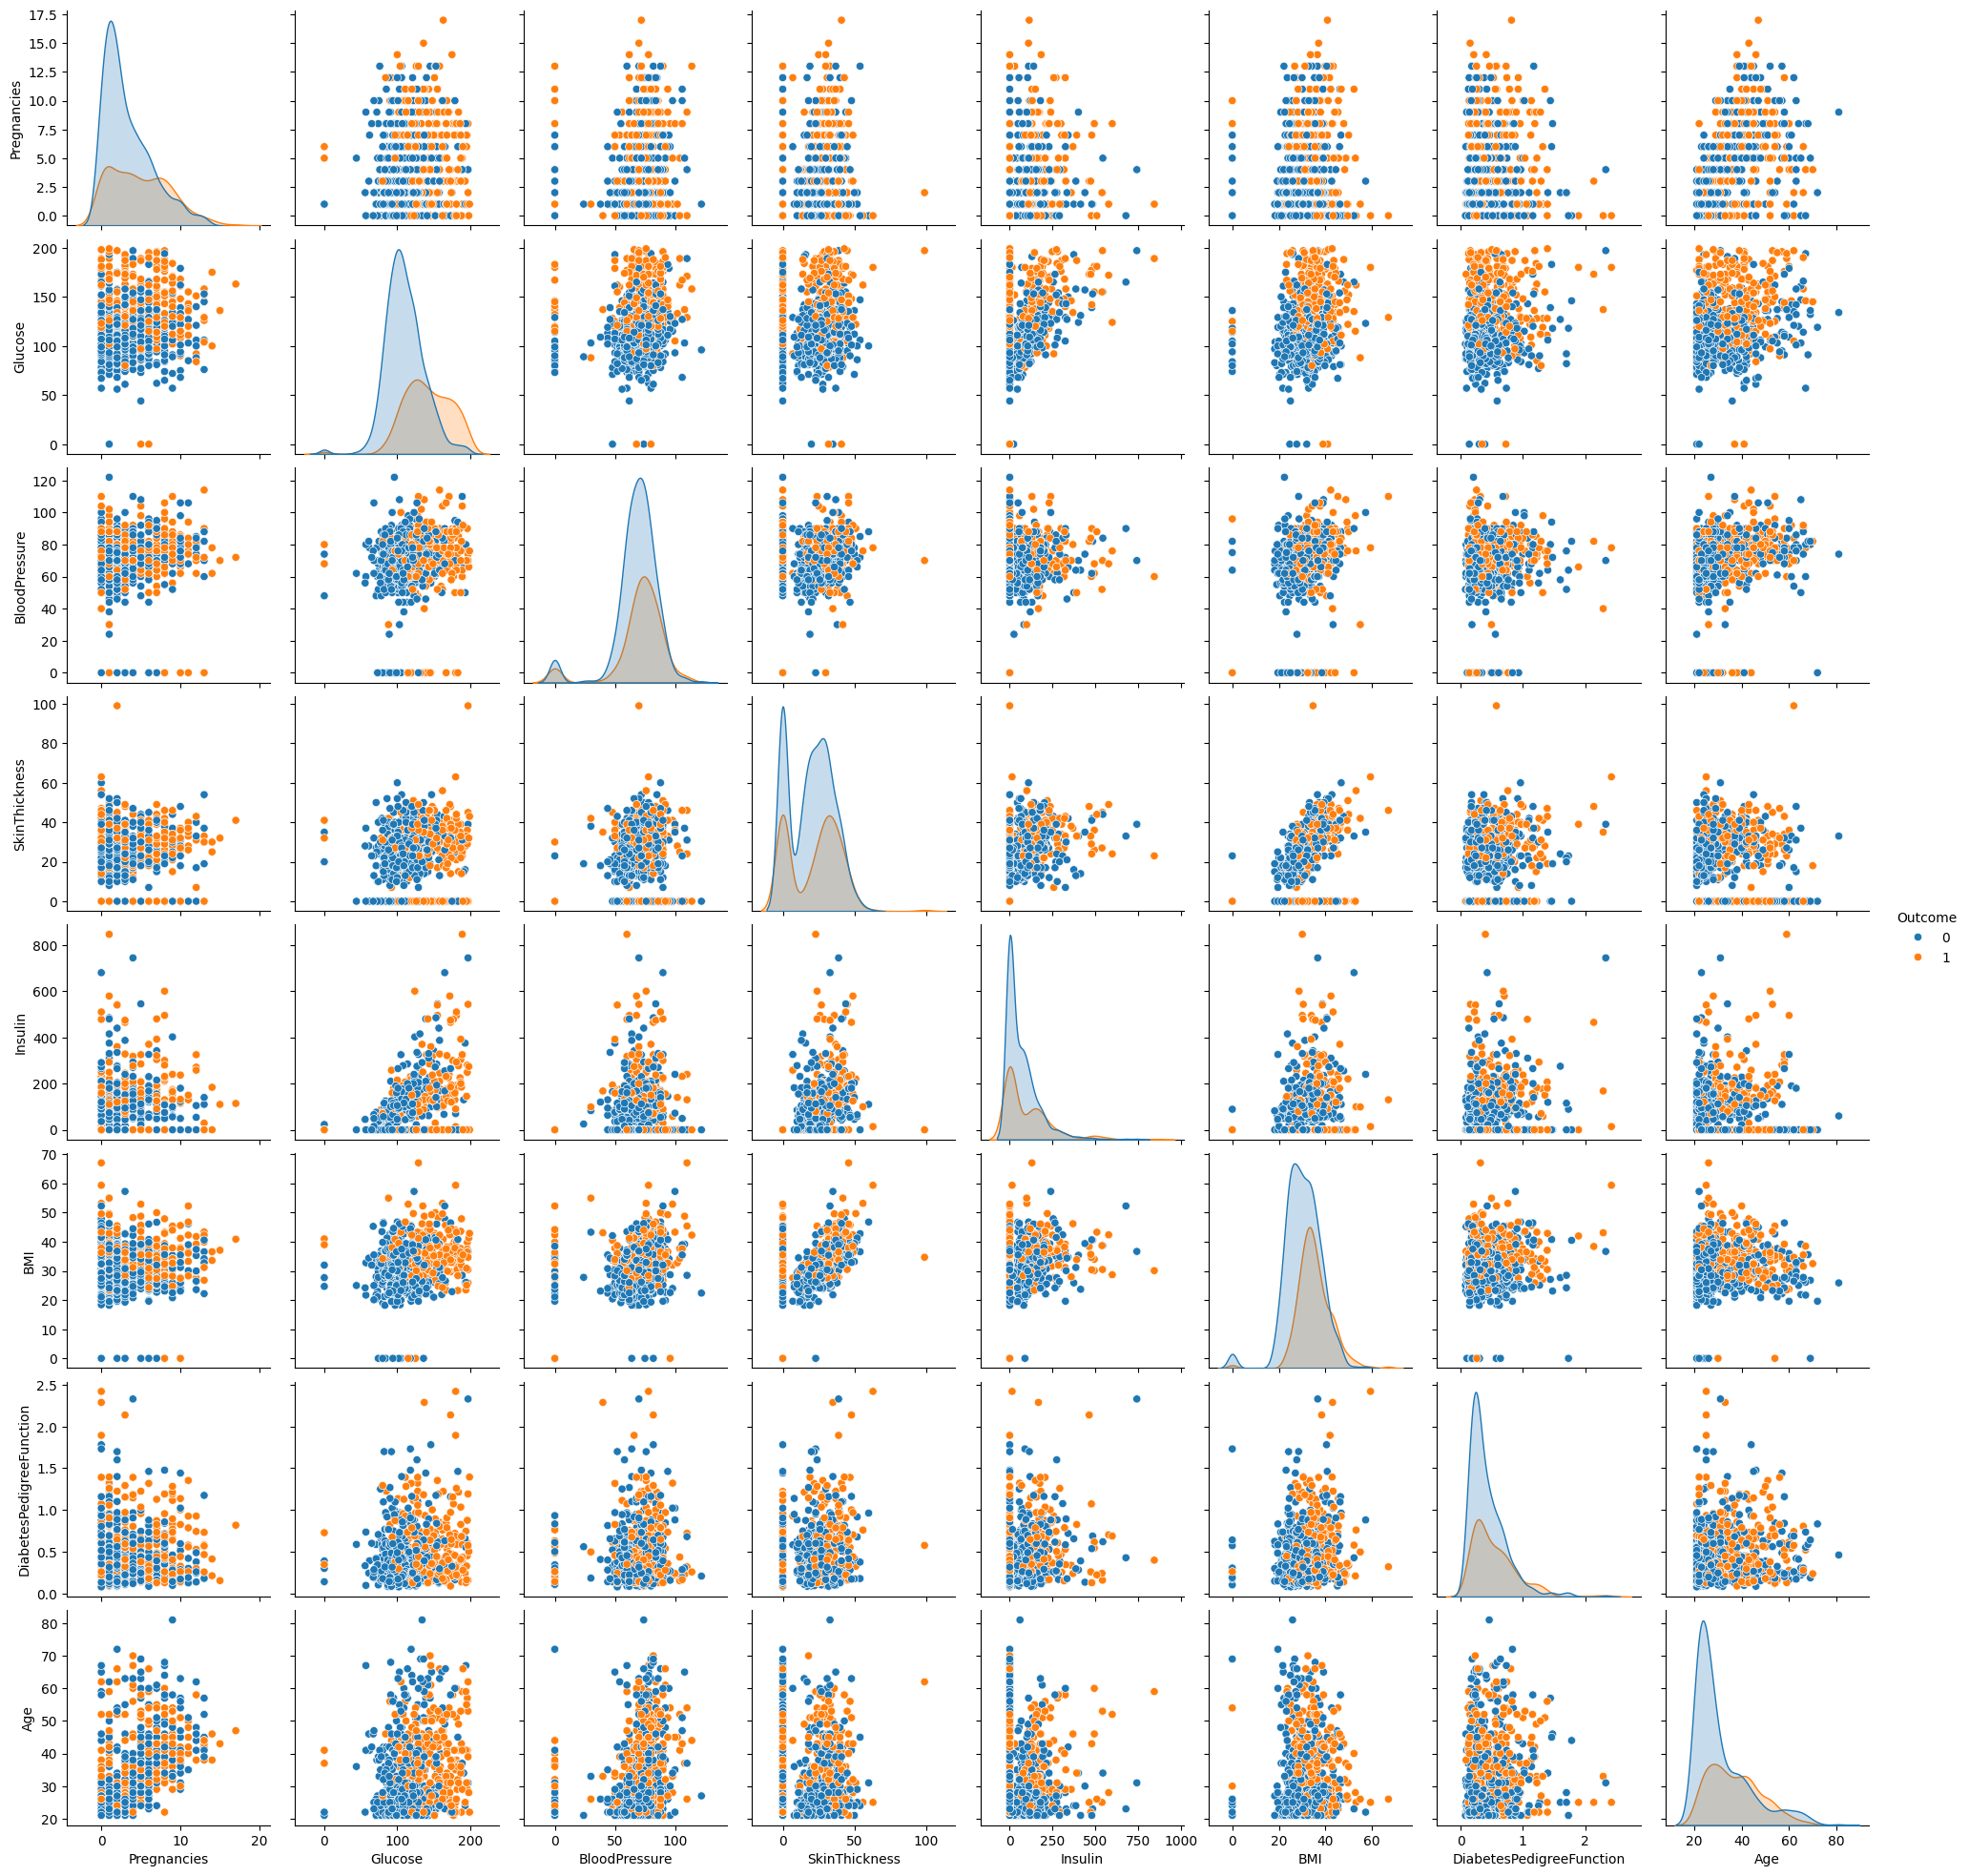

In [ ]:
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='Outcome')
plt.show()

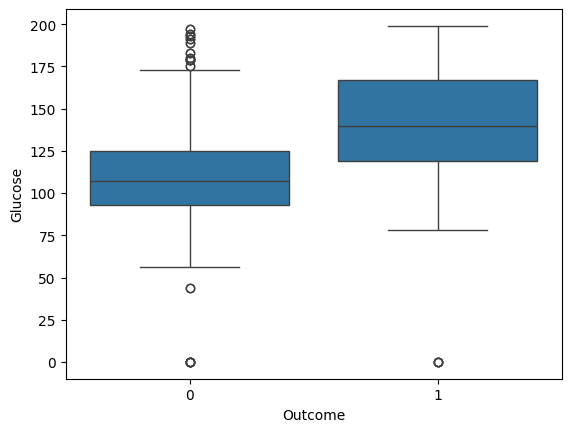

In [ ]:
sns.boxplot(x='Outcome', y='Glucose',data=df)
plt.show()

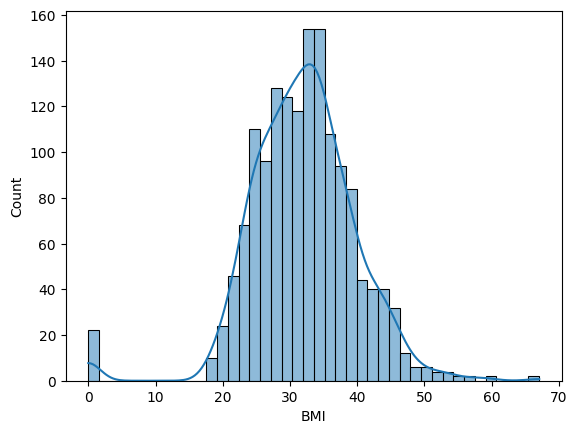

In [ ]:
sns.histplot(df['BMI'],kde=True)
plt.show()

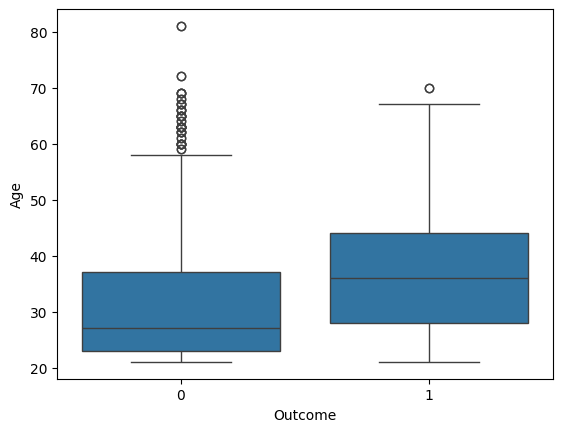

In [ ]:
sns.boxplot(x='Outcome', y='Age',data=df)
plt.show()

In [ ]:

df['Glucose_BMI_Interaction'] = df['Glucose'] * df['BMI']
df['Glucose_Age_Interaction'] = df['Glucose'] * df['Age']
df['BMI_Age_Interaction'] = df['BMI'] * df['Age']
df['Pregnancies_Age_Interaction'] = df['Pregnancies'] * df['Age']


df['Glucose_Insulin_Interaction'] = df['Glucose'] * df['Insulin']
df['BMI_Insulin_Interaction'] = df['BMI'] * df['Insulin']

df['Glucose_BMI_Ratio'] = df['Glucose'] / (df['BMI'] + 1)
df['Insulin_Glucose_Ratio'] = df['Insulin'] / (df['Glucose'] + 1)
df['SkinThickness_BMI_Ratio'] = df['SkinThickness'] / (df['BMI'] + 1)
df['Glucose_Age_Ratio'] = df['Glucose'] / (df['Age'] + 1)

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df=df[~((df < (Q1-1.5*IQR)) | (df > (Q3+1.5*IQR))).any(axis=1)]

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucose_BMI_Interaction,Glucose_Age_Interaction,BMI_Age_Interaction,Pregnancies_Age_Interaction,Glucose_Insulin_Interaction,BMI_Insulin_Interaction,Glucose_BMI_Ratio,Insulin_Glucose_Ratio,SkinThickness_BMI_Ratio,Glucose_Age_Ratio
0,6,148,72,35,0,33.6,0.627,50,1,4972.8,7400,1680.0,300,0,0.0,4.277457,0.000000,1.011561,2.901961
1,1,85,66,29,0,26.6,0.351,31,0,2261.0,2635,824.6,31,0,0.0,3.079710,0.000000,1.050725,2.656250
3,1,89,66,23,94,28.1,0.167,21,0,2500.9,1869,590.1,21,8366,2641.4,3.058419,1.044444,0.790378,4.045455
5,5,116,74,0,0,25.6,0.201,30,0,2969.6,3480,768.0,150,0,0.0,4.360902,0.000000,0.000000,3.741935
6,3,78,50,32,88,31.0,0.248,26,1,2418.0,2028,806.0,78,6864,2728.0,2.437500,1.113924,1.000000,2.888889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1530,9,89,62,0,0,22.5,0.142,33,0,2002.5,2937,742.5,297,0,0.0,3.787234,0.000000,0.000000,2.617647
1532,2,122,70,27,0,36.8,0.340,27,0,4489.6,3294,993.6,54,0,0.0,3.227513,0.000000,0.714286,4.357143
1533,5,121,72,23,112,26.2,0.245,30,0,3170.2,3630,786.0,150,13552,2934.4,4.448529,0.918033,0.845588,3.903226
1534,1,126,60,0,0,30.1,0.349,47,1,3792.6,5922,1414.7,47,0,0.0,4.051447,0.000000,0.000000,2.625000


In [ ]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
    )

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
    )

In [ ]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(random_state=42)
X_train,y_train=sm.fit_resample(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score
import pandas as pd

models= {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(),
    "KNN": KNeighborsClassifier()
}

In [ ]:
#Empty list to store results
results=[]
#Loop through models
for name,model in models.items():
  #Train model
    model.fit(X_train,y_train)
    #Prediction
    y_pred=model.predict(X_test)
    #metrics
    acc=accuracy_score(y_test,y_pred)
    prec=precision_score(y_test,y_pred)
    rec=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    #append results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1_score
    })

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


                    Model  Accuracy  Precision    Recall  \
0     Logistic Regression  0.717949   0.506494  0.582090   
1           Decision Tree  0.914530   0.898305  0.791045   
2           Random Forest  0.965812   0.968254  0.910448   
3  Support Vector Machine  0.700855   0.485149  0.731343   
4                     KNN  0.777778   0.578947  0.820896   

                                F1 Score  
0  <function f1_score at 0x7b7e0a6ed3a0>  
1  <function f1_score at 0x7b7e0a6ed3a0>  
2  <function f1_score at 0x7b7e0a6ed3a0>  
3  <function f1_score at 0x7b7e0a6ed3a0>  
4  <function f1_score at 0x7b7e0a6ed3a0>  


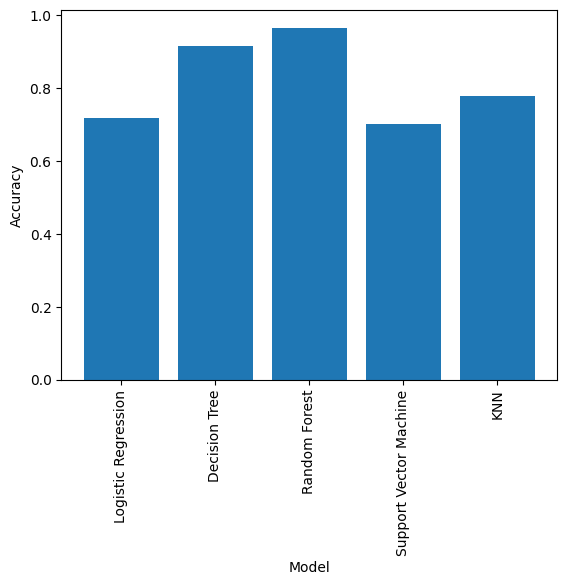

In [ ]:
# Create Dataframe
results_df = pd.DataFrame(results)
# Display results
print(results_df)


plt.bar(results_df['Model'], results_df['Accuracy'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=90)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


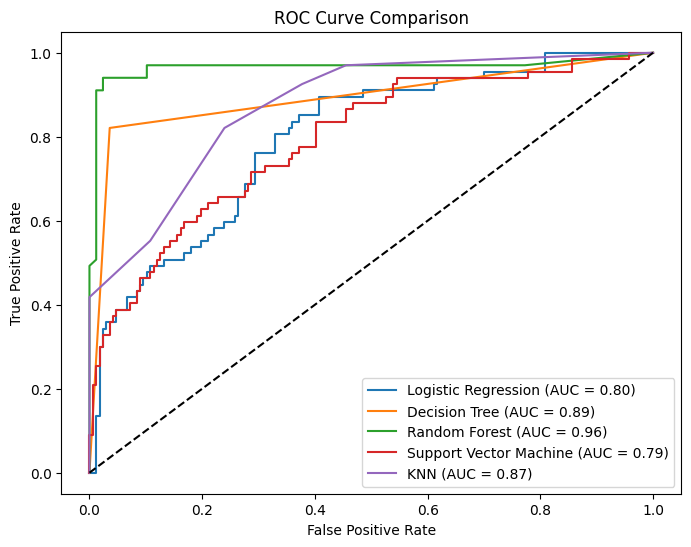

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)

    # Get probability scores
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # ROC calculation (OUTSIDE if-else)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    # Plot each model
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot diagonal line ONCE
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

# Show plot ONCE
plt.show()

In [ ]:
best_model=RandomForestClassifier()
best_model.fit(X_train,y_train)
pred_rf=best_model.predict(X_test)
#

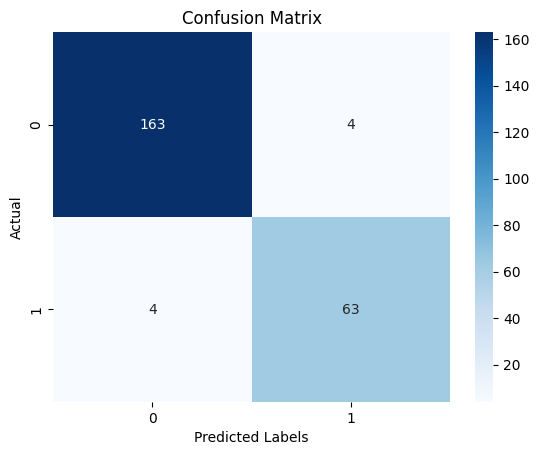

In [ ]:
cm=confusion_matrix(y_test,pred_rf)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual")
plt.show()


In [ ]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       167
           1       0.94      0.94      0.94        67

    accuracy                           0.97       234
   macro avg       0.96      0.96      0.96       234
weighted avg       0.97      0.97      0.97       234



In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
import pickle
pickle.dump(best_model,open('diabetes_model.pkl','wb'))
model=pickle.load(open('diabetes_model.pkl','rb'))
pickle.dump(scaler,open('scaler.pkl','wb'))

In [ ]:
import gradio as gr
import numpy as np
import pickle
model=pickle.load(open('diabetes_model.pkl','rb'))
scaler=pickle.load(open('scaler.pkl','rb'))
def predict_diabetes(Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age):
  GBI = Glucose * BMI
  GBI_Age = Glucose * Age
  BMI_Age = BMI * Age
  PA = Pregnancies * Age
  GI = Glucose * Insulin
  BI = BMI * Insulin
  GBR = Glucose / (BMI + 1)
  IGR = Insulin / (Glucose + 1)
  SBR = SkinThickness / (BMI + 1)
  GAR = Glucose / (Age + 1)
  data = np.array([[Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, GBI, GBI_Age, BMI_Age, PA, GI, BI, GBR, IGR, SBR, GAR]])
  data = scaler.transform(data)
  prediction = model.predict(data)
  result = model.predict(data)
  return "Diabetic" if result[0] == 1 else "Non-Diabetic"
demo = gr.Interface(
    fn=predict_diabetes,
    inputs=[gr.Number(), gr.Number(), gr.Number(), gr.Number(), gr.Number(), gr.Number(), gr.Number(), gr.Number()],
    outputs="text",
    title="Diabetes Prediction",
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://392ff266ec0f3f5422.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
